# Zomato Chennai Data Analysis Project

This CSV dataset contains information pertaining to various Zomato restaurants in Chennai, like restaurant names, cuisine, ratings, features, location, etc.

This dataset will help with answering various questions, like which is the highest rated Seafood Restaurant, or which locality has the best Chinese restaurants, and so on.

## 1. Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import warnings

pio.renderers.default = "svg"
warnings.filterwarnings('ignore')

## 2. Importing the dataset

In [2]:
raw_df = pd.read_csv('Zomato_Chennai_Dataset.csv')

In [3]:
raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


## 3. Getting Basic Information about the Dataset

In [4]:
raw_df.shape

(12032, 12)

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [6]:
raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


## 4. Cleaning the Dataset

The objective of data cleaning is to handle missing values, correct data types and prepare the dataset for accurate analysis and visualization.

### a. Removing the redundunt rows of data

In [7]:
# Dropping columns which are not required for further analysis
raw_df.drop(['Zomato URL'], axis = 1, inplace=True)

In [8]:
raw_df.head()

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


### b. Checking missing values

In [9]:
# Checking for Null records
raw_df.isnull().sum()

Name of Restaurant          0
Address                     0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [10]:
# Checking for a null row
raw_df[raw_df['Price for 2'].isnull()]

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


### c. Checking unique values in each column

In [11]:
for col in raw_df.columns:
    print("Column:", col)
    print(raw_df[col].unique())
    print("----------------------")

Column: Name of Restaurant
['Yaa Mohaideen Briyani' 'Sukkubhai Biriyani' 'SS Hyderabad Biryani' ...
 'House of Candy' 'OVO and LATTEE' "CK's Sandwiches"]
----------------------
Column: Address
[' 336 & 338, Main Road, Pallavaram, Chennai'
 ' New 14, Old 11/3Q, Railway Station Road, MKN Road, Near Antony Church, Alandur, Chennai'
 ' 98/339, Arcot Road, Opposite Gokulam Chit Funds, Kodambakkam, Chennai'
 ... ' 18, Shop 1, Ground Floor, Station View Road, Kodambakkam, Chennai'
 ' New 86, Old 72, Ground Floor, 4th Avenue, Ashok Nagar, Chennai'
 ' 21/10, Rajeswari Tower, Bungalow, 1st Street, Ekkaduthangal, Chennai']
----------------------
Column: Location
['Pallavaram' 'Alandur' 'Kodambakkam' 'Perambur' 'Medavakkam' 'Navallur'
 'Anna Nagar East' 'T. Nagar' 'Velachery' 'Vadapalani' 'Porur' 'Kilpauk'
 'Purasavakkam' 'Ashok Nagar' 'Chetpet' 'Phoenix Market City, Velachery'
 'Aminijikarai' 'Ramapuram' 'Mylapore' 'Thuraipakkam' 'RA Puram'
 'Alwarpet' 'Mogappair' 'West Mambalam' 'Adyar' 'Nungamb

<h5 style="color:darkblue;"> 
• The rating-related columns are expected to contain numerical values. <br>
• However, based on initial observation of the dataset (data types and missing values), these columns are having inconsistent data. <br>
• Therefore, I suspect that they may contain non-numeric text values such as ‘Does not offer Dining’ or ‘Not enough reviews’. <br>
• To confirm this, I am checking the unique values in these columns.
</h5>

In [12]:
cols = ['Dining Rating', 'Delivery Rating', 'Dining Rating Count', 'Delivery Rating Count']

for col in cols:
    print(col, raw_df[col].unique())
    print("----------------------")

Dining Rating [4.3 4.4 4.  4.2 4.1 nan 3.9 4.5 4.7 3.5 4.6 3.6 3.8 4.9 4.8 3.7 2.7 2.9
 2.6 3.  3.4 2.4 3.3 2.8 2.1 2.  2.2 3.2 2.5 3.1 2.3 1.9 1.7 0.3 1. ]
----------------------
Delivery Rating [4.3 4.1 4.4 4.  3.8 4.2 3.9 3.6 nan 3.3 3.4 3.7 3.5 4.5 2.9 4.6 3.1 2.7
 3.2 3.  2.8 2.3 2.4 2.5 4.7 2.6 2.2 2.1 2.  1.8 1.6 1.5 0.3]
----------------------
Dining Rating Count ['1500' '3059' '1361' '1101' '617' '567' 'Does not offer Dining' '668'
 '2564' '1578' '743' '961' '982' '770' '1266' '1094' '1363' '742' '354'
 '660' '802' '578' '1992' '464' '782' '1180' '1139' '457' '625' '1030'
 '1118' '403' '602' '455' '350' '646' '429' '1085' '704' '712' '692' '601'
 '774' '1059' '409' '946' '559' '2162' '523' '908' '1082' '565' '2275'
 '1288' '2449' '835' '842' '1009' '1152' '2485' '731' '1516' '1135' '1078'
 '1225' '849' '768' '2252' '854' '1349' '1943' '460' '1262' '5407' '3042'
 '1096' '983' '771' '345' '585' '1027' '669' '1124' '1198' '515' '447'
 '920' '9410' '763' '741' '609' '979' '954' '1

<h5 style="color:darkblue;"> 
    • The output shows that these columns contain both numeric values and text values such as ‘Does not offer Dining’, ‘Does not offer Delivery’, and ‘Not enough reviews’. <br>
    • These text values are not suitable for numerical analysis. <br>
    • Therefore, non-numeric entries should be replaced with NaN and the columns should be converted into appropriate numeric data types for further analysis.</h5>

### d. Handling Special Text Values

In [13]:
# Columns which contain text like “Does not offer Dining”, should not be treated as numbers.
cols = ['Dining Rating', 'Dining Rating Count', 'Delivery Rating', 'Delivery Rating Count']

for col in cols:
    raw_df[col] = raw_df[col].replace({
        'Does not offer Dining': np.nan,
        'Does not offer Delivery': np.nan,
        'Not enough Dining Reviews': np.nan,
        'Not enough Delivery Reviews': np.nan,
        'None': np.nan
    })

### e. Converting the DataTypes of numerical columns to numeric dataype

In [14]:
for col in cols:
    raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')

In [15]:
raw_df.dtypes

Name of Restaurant        object
Address                   object
Location                  object
Cuisine                   object
Top Dishes                object
Price for 2              float64
Dining Rating            float64
Dining Rating Count      float64
Delivery Rating          float64
Delivery Rating Count    float64
Features                  object
dtype: object

### f. Creating Useful Flags to identify whether services are available

In [16]:
raw_df['Dining Available'] = raw_df['Dining Rating'].notnull()
raw_df['Delivery Available'] = raw_df['Delivery Rating'].notnull()

In [17]:
raw_df.head()

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features,Dining Available,Delivery Available
0,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500.0,4.3,9306.0,"['Home Delivery', 'Indoor Seating']",True,True
1,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059.0,4.1,39200.0,"['Home Delivery', 'Free Parking', 'Table booki...",True,True
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361.0,4.4,10500.0,"['Home Delivery', 'Indoor Seating']",True,True
3,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101.0,4.0,11200.0,"['Home Delivery', 'Free Parking', 'Card Upon D...",True,True
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617.0,4.1,22400.0,"['Home Delivery', 'Indoor Seating']",True,True


### g. Handling Missing Values

<h4 style="color:darkblue;"> 
    • From the above analysis, it is observed that only rating-related columns contain missing values. <br> <br>
    • The null values in the rating columns were not filled or replaced because they represent situations like ‘does not offer service’ or ‘not enough reviews’, so they are not actual missing data. <br> <br>
    • Replacing them would change the meaning of the data, so they were kept as NaN.</h4>

### h. Working on Location column

In [18]:
# Location column contains both area names and specific landmarks such as hotels and malls. 
# Therefore, the main location should be extracted by splitting the values and retaining the actual area name. 

raw_df['Location'] = raw_df['Location'].apply(lambda x: x.split(',')[-1].strip())

In [19]:
raw_df['Location'].unique()

array(['Pallavaram', 'Alandur', 'Kodambakkam', 'Perambur', 'Medavakkam',
       'Navallur', 'Anna Nagar East', 'T. Nagar', 'Velachery',
       'Vadapalani', 'Porur', 'Kilpauk', 'Purasavakkam', 'Ashok Nagar',
       'Chetpet', 'Aminijikarai', 'Ramapuram', 'Mylapore', 'Thuraipakkam',
       'RA Puram', 'Alwarpet', 'Mogappair', 'West Mambalam', 'Adyar',
       'Nungambakkam', 'Royapettah', 'Chromepet', 'Kolathur',
       'Valasaravakkam', 'Guindy', 'Potheri', 'Egmore', 'Madipakkam',
       'Thiruvanmiyur', 'Saligramam', 'Sholinganallur', 'Perungudi',
       'Besant Nagar', 'Kotturpuram', 'Semmancheri', 'Royapuram',
       'Anna Nagar West', 'Grand by GRT Hotels', 'Ambattur',
       'Thousand Lights', 'Kanathur', 'Washermenpet', 'Selaiyur',
       'Old Mahabalipuram Road (OMR)', 'Choolaimedu', 'Abhiramapuram',
       'Triplicane', 'Poonamalle', 'Gopalapuram', 'East Coast Road (ECR)',
       'Kandanchavadi', 'Palavakkam', 'Neelangarai', 'GST Road',
       'MRC Nagar', 'T.Nagar', 'RK Salai (

In [20]:
# Standardizing similar names
raw_df['Location'] = raw_df['Location'].replace({
    'T.Nagar': 'T. Nagar',
    'RA Puram': 'R.A. Puram',
    'Redhills': 'Red Hills',
    'OMR': 'Old Mahabalipuram Road',
    'Mamallapuram': 'Mahabalipuram'})

In [21]:
# Handling non-location values
non_location = ['Grand by GRT Hotels', 'Foodies Kitchen', 'Citadines',
                'A Radha Hotel', 'V7 Hotel', 'The Slate']

raw_df['Location'] = raw_df['Location'].replace(non_location, np.nan)

In [22]:
# How many rows with broken value 'East...'
raw_df[raw_df['Location'] == 'East...']

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features,Dining Available,Delivery Available
1147,KoKoMMo,Inter Continental Chennai Mahabalipuram Resor...,East...,['Finger Food'],"['Cocktails', ' Fries', ' Dal Makhani']",1500.0,4.0,137.0,NaN,NaN,"['Full Bar Available', 'Live Sports Screening'...",True,False


In [23]:
# Remove broken values
raw_df = raw_df[raw_df['Location'] != 'East...']

In [24]:
# Final check
raw_df['Location'].nunique()
raw_df['Location'].value_counts().head(20)

Location
Velachery          421
Porur              421
Ambattur           361
T. Nagar           340
Perungudi          288
Anna Nagar East    285
Nungambakkam       279
Perambur           277
Medavakkam         271
Tambaram           258
Ramapuram          252
Anna Nagar West    245
Thuraipakkam       243
Mogappair          220
Selaiyur           218
Kilpauk            206
GST Road           203
Madipakkam         202
Adyar              201
Pallavaram         192
Name: count, dtype: int64

### i. Working on cuisine, top dishes and features columns

In [25]:
# Checking the type
for col in ['Cuisine', 'Top Dishes', 'Features']:
    print(col, type(raw_df[col].iloc[0]))  # This checks ONLY ONE row

Cuisine <class 'str'>
Top Dishes <class 'str'>
Features <class 'str'>


In [26]:
for col in ['Cuisine', 'Top Dishes', 'Features']:
    print(col)
    print(raw_df[col].apply(type).value_counts())  # This checks for all rows
    print("------------")

Cuisine
Cuisine
<class 'str'>    12031
Name: count, dtype: int64
------------
Top Dishes
Top Dishes
<class 'str'>    12031
Name: count, dtype: int64
------------
Features
Features
<class 'str'>    12031
Name: count, dtype: int64
------------


In [27]:
# Converting into list
import ast

cols = ['Cuisine', 'Top Dishes', 'Features']

def convert_to_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []   # if error → make it empty list
    return x

for col in cols:
    raw_df[col] = raw_df[col].apply(convert_to_list)

In [28]:
for col in cols:
    print(col, type(raw_df[col].iloc[0]))

Cuisine <class 'list'>
Top Dishes <class 'list'>
Features <class 'list'>


In [29]:
# Removing extra spaces
for col in cols:
    raw_df[col] = raw_df[col].apply(
        lambda x: [i.strip() for i in x] if isinstance(x, list) else [])

### j. Handling Duplicates

In [30]:
# When checking duplicate values, the function duplicated() needs hashable values (like strings, numbers).
# But our dataset contains lists (cuisines, top dishes and features columns) which are unhashable type.
# So, checking duplicates using only important columns here. (Restaurant name + location => unique identity)

raw_df.duplicated(subset=['Name of Restaurant', 'Location', 'Address']).sum()

28

In [31]:
# Removing duplicates
raw_df = raw_df.drop_duplicates(subset=['Name of Restaurant', 'Location', 'Address'])

In [32]:
raw_df.duplicated(subset=['Name of Restaurant', 'Location', 'Address']).sum()

0

## 5. Copying the cleaned data into a new DataFrame

In [33]:
clean_df = raw_df.copy()

In [34]:
clean_df.head()

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features,Dining Available,Delivery Available
0,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,[Biryani],"[Bread Halwa, Chicken 65, Mutton Biryani, Chic...",500.0,4.3,1500.0,4.3,9306.0,"[Home Delivery, Indoor Seating]",True,True
1,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"[Biryani, North Indian, Mughlai, Desserts, Bev...","[Beef Biryani, Beef Fry, Paratha, Paya, Brinja...",1000.0,4.4,3059.0,4.1,39200.0,"[Home Delivery, Free Parking, Table booking re...",True,True
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"[Biryani, North Indian, Chinese, Arabian]","[Brinjal Curry, Tandoori Chicken, Chicken Gril...",500.0,4.3,1361.0,4.4,10500.0,"[Home Delivery, Indoor Seating]",True,True
3,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"[Burger, Fast Food, Finger Food, Beverages]",[Zinger Burger],500.0,4.0,1101.0,4.0,11200.0,"[Home Delivery, Free Parking, Card Upon Delive...",True,True
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"[Chinese, Biryani, North Indian, Chettinad, Ar...","[Mutton Biryani, Chicken Rice, Tomato Rice, Sh...",450.0,4.2,617.0,4.1,22400.0,"[Home Delivery, Indoor Seating]",True,True


## 6. Performing Exploratory Data Analysis

EDA is performed to identify patterns in restaurant distribution, pricing, ratings and services.

### Q1) Which locations have the most restaurants?

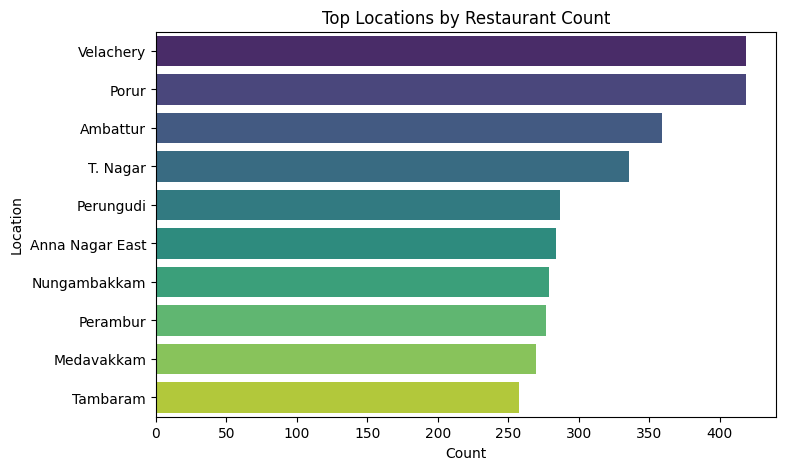

In [49]:
loc_df = clean_df['Location'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=loc_df.values, y=loc_df.index, palette='viridis')
plt.title("Top Locations by Restaurant Count")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

<h5 style="color:darkblue;"> 
• Velachery and Porur have the highest number of restaurants. <br>
• These areas indicate high demand and strong food business activity. <br>
• They could be commercial or residential hotspots. <br>
</h5>

### Q2) What is the average price in each location?

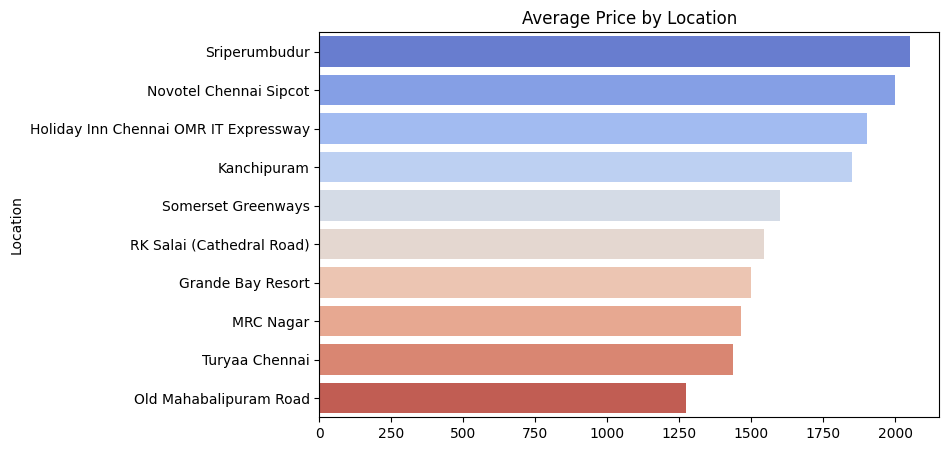

In [55]:
price_loc = clean_df.groupby('Location')['Price for 2'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=price_loc.values, y=price_loc.index, palette="coolwarm")
plt.title("Average Price by Location")
plt.show()

<h5 style="color:darkblue;"> 
    • Sriperumbudur and Novotel Chennai Sipcot areas have higher average prices. <br>
• These locations may contain premium restaurants or resorts.<br>
• Pricing varies significantly across locations.</h5>

## Q3) Distribution of price

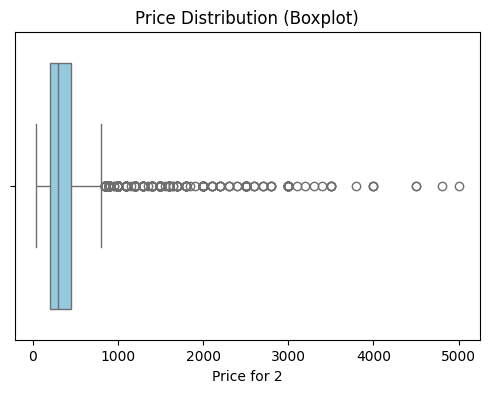

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x=clean_df['Price for 2'], color='skyblue')
plt.title("Price Distribution (Boxplot)")
plt.show()

<h5 style="color:darkblue;"> 
• Most restaurants fall in lower price range (left side).<br>
• Few extreme high-price outliers exist.<br>
• This box whisker plot shows that market is mostly budget-friendly.</h5>

### Q4) Dining rating distribution

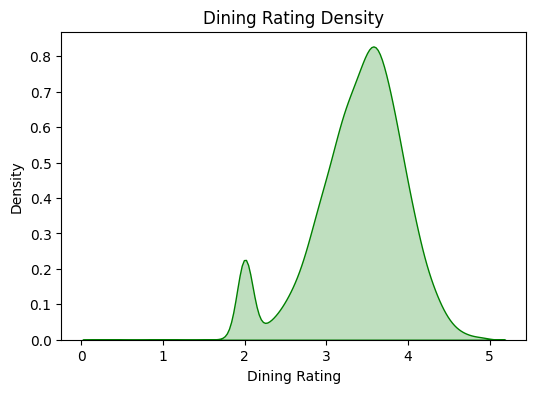

In [57]:
plt.figure(figsize=(6,4))
sns.kdeplot(clean_df['Dining Rating'], fill=True, color='green')
plt.title("Dining Rating Density")
plt.show()

<h5 style="color:darkblue;"> 
    • Most ratings are concentrated between 3.0 to 4.0.<br>
• Very few restaurants have extremely low ratings.<br>
• Overall quality is moderate to good.  </h5>

### Q5) Delivery vs Non-delivery restaurants

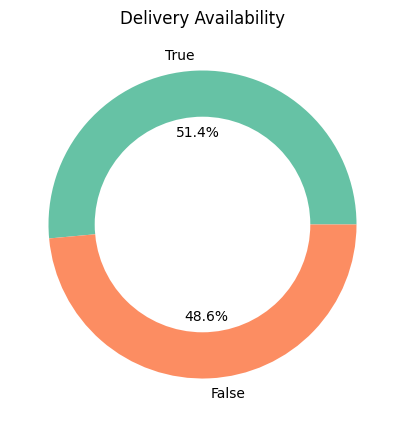

In [59]:
delivery = clean_df['Delivery Available'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(delivery, labels=delivery.index, autopct='%1.1f%%',
        colors=['#66c2a5','#fc8d62'])
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Delivery Availability")
plt.show()

<h5 style="color:darkblue;"> 
    • Slightly more than half of restaurants offer delivery.<br>
• This indicates balanced market between dine-in and delivery.</h5>

### Q6) Do delivery restaurants have better ratings?

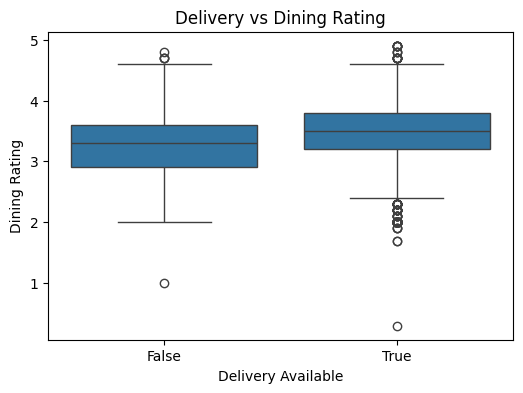

In [60]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Delivery Available', y='Dining Rating', data=clean_df)
plt.title("Delivery vs Dining Rating")
plt.show()

<h5 style="color:darkblue;"> • Delivery restaurants show slightly higher median ratings.<br>
• However, rating spread is similar across both groups.<br>
• Delivery does not strongly impact rating quality.</h5>

### Q7) Top 10 Cuisines

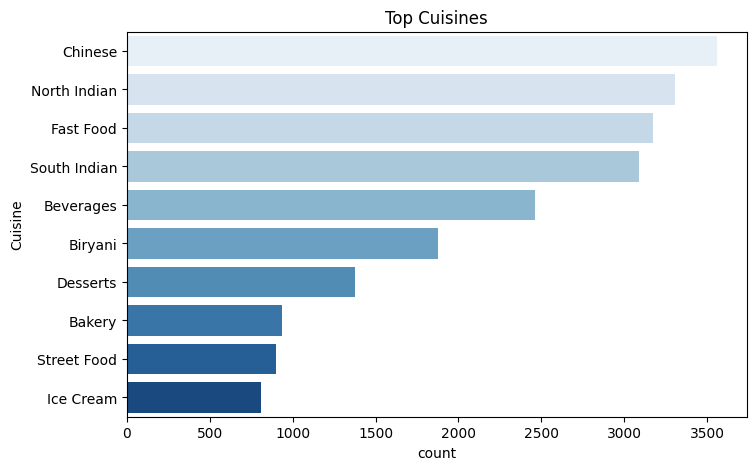

In [72]:
cuisine_df = clean_df.explode('Cuisine').reset_index(drop=True)

plt.figure(figsize=(8,5))
sns.countplot(y='Cuisine', data=cuisine_df,
              order=cuisine_df['Cuisine'].value_counts().head(10).index,
              palette='Blues')

plt.title("Top Cuisines")
plt.show()

<h5 style="color:darkblue;"> • Chinese and North Indian cuisines are most popular.<br>
• Fast food and South Indian also have strong presence.<br>
• This indicates diverse food preferences.</h5>

### Q8) Top 10 Dishes

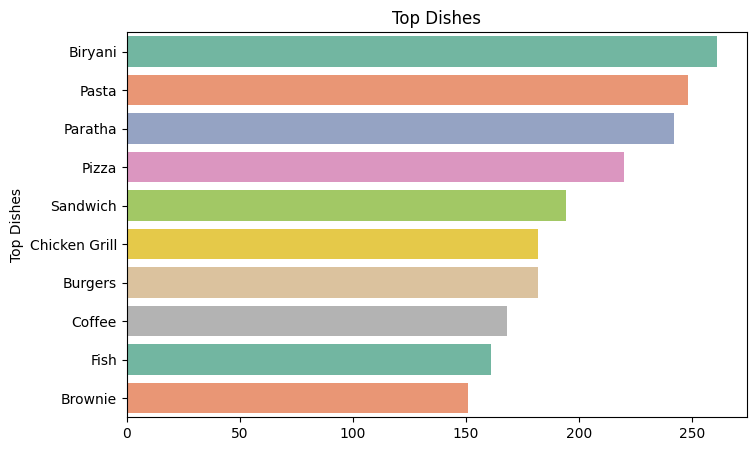

In [69]:
dish_df = clean_df.explode('Top Dishes')

top_dishes = dish_df['Top Dishes'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_dishes.values, y=top_dishes.index, palette="Set2")
plt.title("Top Dishes")
plt.show()

<h5 style="color:darkblue;"> 
    • Biryani is the most popular dish.<br>
• Fast food items like pizza and burgers are also common.<br>
• This shows a mix of traditional and modern preferences.</h5>

### Q9) Relationship between price and rating

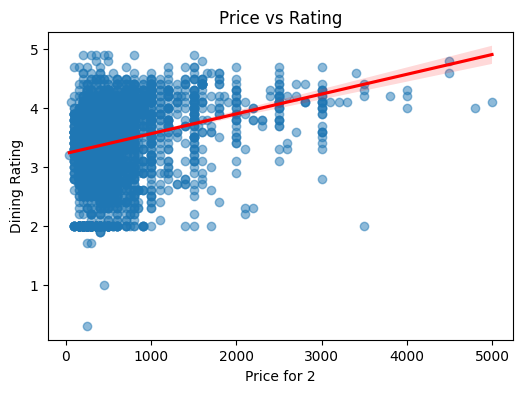

In [66]:
plt.figure(figsize=(6,4))
sns.regplot(x='Price for 2', y='Dining Rating', data=clean_df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Price vs Rating")
plt.show()

<h5 style="color:darkblue;"> • Slight positive relationship between price and rating.<br>
• Higher price does not always guarantee better ratings.<br>
• Quality depends on more than just price.</h5>

### Q10) Which locations have highest rated restaurants?

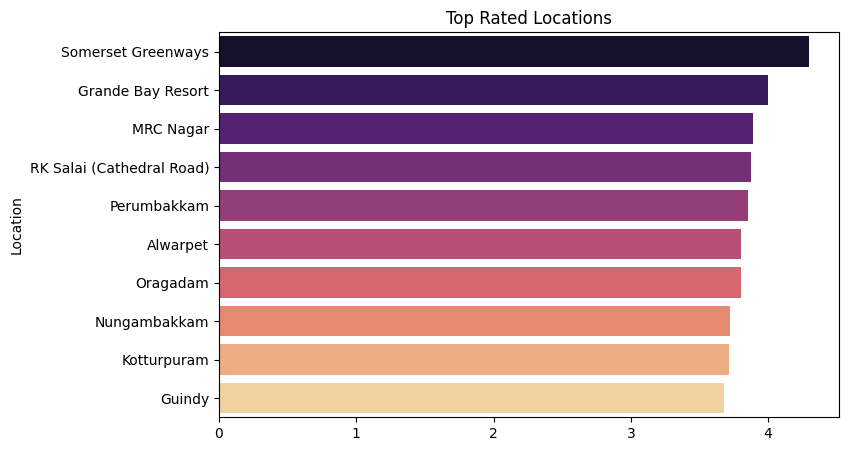

In [67]:
rating_loc = clean_df.groupby('Location')['Dining Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=rating_loc.values, y=rating_loc.index, palette="magma")
plt.title("Top Rated Locations")
plt.show()

<h5 style="color:darkblue;"> • Locations like Somerset Greenways show highest ratings.<br>
• Premium areas tend to have better-rated restaurants.<br>
• Quality varies across locations.</h5>